In [63]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Code sources:
# https://stackoverflow.com/questions/33503993/read-in-all-csv-files-from-a-directory-using-python
# https://stackoverflow.com/questions/5137497/find-the-current-directory-and-files-directory
# https://stackoverflow.com/questions/9572490/find-index-of-last-occurrence-of-a-substring-in-a-string

def loadData(datatype):
    X_data = []
    y_data = []
    # Directory path to the data
    directory_path = os.path.abspath(os.path.join(os.getcwd(),'..',datatype))
    print(directory_path)

    for filename in glob.glob(os.path.join(directory_path, '*.csv')):
        # Extracting the class labels from the filenames
        y = int(filename[filename.rindex('_0')-1])
        y_data.append(y)

        # Read the csv data file and convert into numpy array
        x = np.genfromtxt(filename, delimiter=',')
        X_data.append(x)

    # Checking classes and their counts
    values, counts = np.unique(y_data, return_counts=True)

    print(f'The data has {len(X_data)} samples with {values} classes and respectively their counts {counts}.')

    return X_data, y_data

X_train_init, y_train_init = loadData('training_data')
# not needed in the final classifying function

C:\Users\heikk\AppData\Local\Programs\training_data
The data has 1000 samples with [0 1 2 3 4 5 6 7 8 9] classes and respectively their counts [100 100 100 100 100 100 100 100 100 100].


In [64]:
def standardize_data(X_data):
    X_data_std = [] # Standardized data
    for i in range(len(X_data)):
        X = X_data[i]
        # Standardization Z = (X-µ) / σ for each column
        mu = X.mean(axis=0)
        sigma = X.std(axis=0, ddof=1) # Sample standard deviation
        Z = (X - mu) / sigma
        X_data_std.append(Z)

    return X_data_std # Returns the standardized data as a numpy array
X_train_std = standardize_data(X_train_init)

In [ ]:
# Sources of feature extraction ideas and some example codes:
# https://github.com/yogeshgajjar/logistic_regression/blob/master/logistic_regression_classification.ipynb
# https://www.geeksforgeeks.org/data-analysis/feature-engineering-for-time-series-data-methods-and-applications/#1-statistical-features
# https://towardsdatascience.com/applications-of-rolling-windows-for-time-series-with-python-1a4bbe44901d/

import numpy as np
import pandas as pd
from scipy.stats import skew

# Function takes the time series data and labels as input and forms a new pandas dataset 
def feature_extract(X_data, y_data):
    new_X_train = []
    # Extracting features from the time series data and making a simpler dataset with class labels
    for i in range(len(X_data)):
        X = [] # Feature sample list

        x = X_data[i] # Time series data sample
        x_len = len(x) # Length of the sample for indexing

        X.append(np.mean(x[2*x_len//8:3*x_len//8]))
        X.append(np.mean(x[3*x_len//8:4*x_len//8]))
        X.append(np.mean(x[4*x_len//8:5*x_len//8]))
        X.append(np.mean(x[5*x_len//8:6*x_len//8]))
        X.append(np.mean(x[6*x_len//8:7*x_len//8]))

        X.append(np.std(x[x_len//8:2*x_len//8], ddof=1))
        X.append(np.std(x[2*x_len//8:3*x_len//8], ddof=1))
        X.append(np.std(x[3*x_len//8:4*x_len//8], ddof=1))
        X.append(np.std(x[4*x_len//8:5*x_len//8], ddof=1))
        X.append(np.std(x[5*x_len//8:6*x_len//8], ddof=1))
        X.append(np.std(x[6*x_len//8:7*x_len//8], ddof=1))

        # Extract max-mins of X in 5 subintervals
        X.append(np.max(x[:x_len//5]) - np.min(x[:x_len//5]))
        X.append(np.max(x[x_len//5:2*x_len//5]) - np.min(x[x_len//5:2*x_len//5]))
        X.append(np.max(x[2*x_len//5:3*x_len//5]) - np.min(2*x[x_len//5:3*x_len//5]))
        X.append(np.max(x[3*x_len//5:4*x_len//5]) - np.min(3*x[x_len//5:4*x_len//5]))

        skewness = skew(x)
        X.extend(skewness)

        # Area under the curve features
        auc1 = np.trapezoid(x[:,1], x[:, 0], dx=5)
        auc3 = np.trapezoid(x[:,0], x[:, 2], dx=5)

        X.append(auc1) 
        X.append(auc3)

        centroid = np.mean(x, axis=0)

        X.append(centroid[0]) # xmean

        X.append(np.trapezoid(x[:x_len//3, 1], x[:x_len//3, 0], dx=5))

        firstLastDist = x[0,:]-x[-1,:] # added euclidian distance
        eucDist = np.linalg.norm(firstLastDist)
        X.append(eucDist)
    
        new_X_train.append(X)

    # New dataset
    dataset = np.array(new_X_train)
    return dataset

data = feature_extract(X_train_std, y_train_init) # Extracting features from the time series data and forming a new pandas dataset

final_y = np.array(y_train_init).astype(int) # no column vector
print(final_y.dtype)
final_X = data # keeping them separate 
print(final_X.shape)

int64
(1000, 23)


# Multinomial Logistic Regression model:

Iteration: 0 , accuracy: 0.1 , validation accuracy 0.1
Iteration: 10 , accuracy: 0.43875 , validation accuracy 0.43
Iteration: 20 , accuracy: 0.7 , validation accuracy 0.705
Iteration: 30 , accuracy: 0.74125 , validation accuracy 0.685
Iteration: 40 , accuracy: 0.735 , validation accuracy 0.715
Iteration: 50 , accuracy: 0.74125 , validation accuracy 0.725
Iteration: 60 , accuracy: 0.80375 , validation accuracy 0.805
Iteration: 70 , accuracy: 0.84 , validation accuracy 0.845
Iteration: 80 , accuracy: 0.84125 , validation accuracy 0.84
Iteration: 90 , accuracy: 0.87 , validation accuracy 0.865
Iteration: 100 , accuracy: 0.89 , validation accuracy 0.89
Iteration: 110 , accuracy: 0.90125 , validation accuracy 0.91
Iteration: 120 , accuracy: 0.9125 , validation accuracy 0.925
Iteration: 130 , accuracy: 0.91375 , validation accuracy 0.925
Iteration: 140 , accuracy: 0.92125 , validation accuracy 0.925
Iteration: 150 , accuracy: 0.9325 , validation accuracy 0.945
Iteration: 160 , accuracy: 0.9

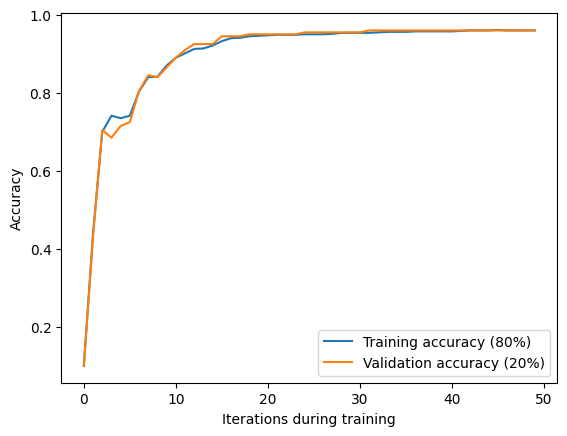

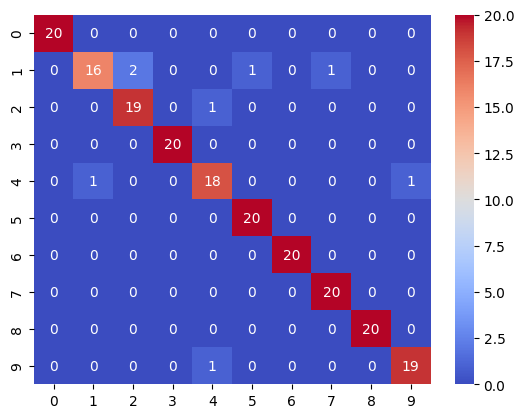

In [74]:
# input: X_train (feature data), y_train (class value vector)
# with these we want to train the MLR model, which means maximizing the likelihood of seeing each class by tuning the weights + biases, through cross-entropy loss.
# output: trained weights and biases for each class, such that the accuracy converges or is maximized during training, ideally
# Sources:
# https://web.stanford.edu/~jurafsky/slp3/old_aug24/7.pdf # primarily softmax related equations (gradient descent: p:15, eq:7.28 , one-hot vectors: p:15, the softmax y_hat function: eq:7.9)
# https://web.stanford.edu/~jurafsky/slp3/old_aug24/5.pdf # primarily the softmax final gradient descent update equation (p:15, eq:5.28 )
# https://stackoverflow.com/questions/29831489/convert-array-of-indices-to-one-hot-encoded-array-in-numpy # primarily for figuring out how to make the one-hot vectors

def sumHelper(N,K,z): # not needed in digit_classify
    Sum_k = np.zeros((N,1))
    for i in range(N):
        sum2 = 0
        for k in range(K):
            sum2 = sum2 + np.exp(z[i,k])
        Sum_k[i, 0] = sum2
    return Sum_k

def MLR_test(W, X_te):
    N,D = X_te.shape
    # augmented features
    x0 = np.ones((N,1)) # column of ones
    x_bias = np.concatenate([X_te,x0], axis=1) # (N,D+1), adding to the end
    z = x_bias @ W.T # logits, (N,K)
    predicted = z.argmax(axis=1) # taking the index value of the largest logit is enough for predictions
    return predicted

def MLR_train(X_tr, y_tr, X_tst, y_tst, alpha, gradientDescentIterations):
    N,D = X_tr.shape
    K = 10
    # plotting
    fig, ax = plt.subplots()
    trainList = []
    validList = []
    # D = number of features in our feature matrix X_tr
    # K = number of classes (hardcoded to 10)
    # N = number of samples in total
    #
    # loop indices:
    # n loops through the samples (N)
    # k loops through the classes (K)

    x0 = np.ones((N,1)) # column of ones
    x = np.concatenate([X_tr,x0], axis=1) # (N,D+1), adding to the end for the bias term

    W = np.zeros((K,D+1)) # augmented weight matrix initialization. (K,D+1)

    t = np.zeros((N, K)) # the one-hot vectors in a matrix, columns correspond to each class: (N,K)
    t[np.arange(N), y_tr] = 1.0

    for i in range(gradientDescentIterations):
        # z = Wx (bias version)
        z = x @ W.T # logits (N,K)

        Sum = sumHelper(N,K,z) # softmax denominator
        # y_hat = softmax(z)
        y_hat = np.exp(z) / Sum

        if(i % 10 == 0): # training accuracy prints
            predicted = y_hat.argmax(axis=1)
            accuracy = np.mean(predicted==y_tr) # compare with testing data to make sure we don't overfit
            valid_accuracy = MLR_test(W, X_tst)
            valAcc = np.mean(valid_accuracy==y_tst)
            print("Iteration:",i,", accuracy:",accuracy,", validation accuracy",valAcc)
            trainList.append(accuracy)
            validList.append(valAcc)

        # gradient descent, updating each class's weights + bias: cross-entropy loss:
        # wk <- wk - alpha * (1/N) * (N)SUM(n=1) [ (y_hat_k^n - t_k^n ] * x(n)
        for k in range(K):
            # we are going row by row down W, which means we are optimizing the weights (+bias) for each class (k) one at a time...
            gradientSum_k = np.zeros(D+1)
            for n in range(N):
                # dL/dW_k = (N)SUM(n=1) [ (y_hat_k^n - t_k^n ] * x(n); predicted (y_hat), true(t). Class-specific probabilities in (y_hat), and the one-hot columns in (t) correspond to the same classes...
                gradientSum_k = gradientSum_k + (y_hat[n,k] - t[n,k]) * x[n,:]
                # row (n), column (k)

            # wk <- wk - alpha * (1/N) * gradientSum_k
            W[k,:] = W[k,:] - alpha * (1/N) * gradientSum_k # updating class-specific weights one at a time to the column

    Xrange = np.arange(0,gradientDescentIterations/10,1)
    ax.plot(Xrange, trainList, label = "Training accuracy (80%)")
    ax.plot(Xrange, validList, label = "Validation accuracy (20%)")
    ax.set_xlabel("Iterations during training")
    ax.set_ylabel("Accuracy")
    ax.legend()
    plt.figure()

    return W # in all essence, this function returns the weights (and the bias) for each class, such that class1 is a row vector at the top, class 2 the second row vector and so on.

# standard train/test split with premade function
X_train, X_test, y_train, y_test = train_test_split(final_X, final_y, test_size=0.2, stratify=final_y) # currently always the same test/train sets to see how changing the alpha
                                                                                                                       # and gradientDescentIterations affects things...

W = MLR_train(X_train, y_train, X_test, y_test, alpha = 0.5, gradientDescentIterations = 500)

y_pred = MLR_test(W, X_test)

CR_RF = classification_report(y_test, y_pred)
CM_RF = confusion_matrix(y_test, y_pred)
print(CR_RF)
sns.heatmap(CM_RF, annot=True, cmap = "coolwarm")
plt.show()

In [76]:
# spitting out the final weight+bias matrix for hardcoding, there probably are better ways of doing this:
print("W=np.array("+repr(W.tolist())+",dtype=float)")
print(W.shape)

W=np.array([[-0.8936027243761147, -0.2668586101838369, -0.016641176384581947, 0.25975570336776954, 1.2792262727318608, -0.016039763969446817, 0.04830763952639096, 0.5029112640441542, 0.1312387306042511, 0.1853056514293579, -0.12442886963355448, 0.5191786266452132, 0.32475358207528643, -0.15248961318711027, -0.24457554851636762, -0.07289273711269081, -0.6684564962582563, 0.15942883768119626, -2.501202383786621, -0.612644771235329, 2.237486750786423e-17, 0.8923414202690525, -2.451155582042803, 0.08406013927325018], [1.2694716534282469, -0.13941794032967128, -0.6580832536580212, -0.8598618254555712, -1.0490813153160088, -0.03221761281700561, 0.13606813561977713, -0.25352451763482386, -0.031125690494224593, -0.05138471844441785, 0.12578407164484326, 0.04100764599664019, -0.8022566686268633, 0.42634348254688975, 0.11991745552074355, 0.6608310288137973, 0.7752734462016805, 0.10005627642586791, 0.5157604688450134, -0.03502862629005563, -3.869926615770698e-15, 0.4325609371916654, 0.90356634400